# LAB 8


## Task 1.1  Dataset, vocabulario y batches

### Referencias
ChatGPT, se utilizo para darle la estructura al ipynb y darle formato a las respuestas.
Prompt: Puedes reestructurar mi .py y mi .txt en un archivo .ipynb juntandolos y dandoles un formato profesional.
Funciona porque lo alimente con las tasks ya completas, graficas e información completa sobre el Mini-GPT y solo le pedi que organizara toda la información para que tuviera un formato más legible y mejorando las respuestas a las preguntas y dandoles un poco más de contexto.

In [ ]:
import math, os, time, urllib.request
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 1337
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


block_size = 128
d_model    = 128
n_heads    = 4
n_layers   = 3
batch_size = 64
lr         = 3e-4
epochs     = 10


steps_per_epoch = 500
dropout = 0.1     
grad_clip = 1.0  

device: cpu


In [ ]:
#descarga
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(URL, "input.txt")
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()
print("caracteres totales:", len(text))
print(text[:200])

caracteres totales: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [ ]:

chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, f"Se esperaban 65 caracteres y hay {vocab_size}"  

stoi = {ch: i for i, ch in enumerate(chars)}   
itos = {i: ch for ch, i in stoi.items()}      

def encode(s):  return [stoi[c] for c in s]
def decode(ids): return "".join(itos[int(i)] for i in ids)


assert decode(encode("ROMEO:")) == "ROMEO:"
print("vocab_size:", vocab_size)
print(repr("".join(chars)))

vocab_size: 65
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


In [ ]:

data = torch.tensor(encode(text), dtype=torch.long)

# Split 90/10 
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print("train:", len(train_data), "val:", len(val_data))

train: 1003854 val: 111540


In [ ]:
def get_batch(split):

    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))   
    x = torch.stack([d[i : i + block_size] for i in ix])
    y = torch.stack([d[i + 1 : i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print(xb.shape, yb.shape)

print(repr(decode(xb[0, :20])));  print(repr(decode(yb[0, :20])))

torch.Size([64, 128]) torch.Size([64, 128])
' if die, be brief,\nT'
'if die, be brief,\nTh'


## Task 1.2 
Mini-GPT, entrenamiento y perplejidad

In [ ]:

class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        assert d_model % n_heads == 0
        self.qkv = nn.Linear(d_model, 3 * d_model) 
        self.proj = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(d_model, dim=2)

        q, k, v = [t.view(B, T, n_heads, C // n_heads).transpose(1, 2) for t in (q, k, v)]
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=dropout if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.drop(self.proj(y))

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention()
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(),
                                 nn.Linear(4 * d_model, d_model), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))  
        x = x + self.mlp(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)  
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block() for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.apply(self._init)

    def _init(self, m):
        # Inicialización N(0, 0.02) estilo GPT-2
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        x = self.ln_f(self.blocks(x))
        logits = self.head(x)                                   
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

model = MiniGPT().to(device)
print(f"parámetros: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

parámetros: 0.63 M


In [ ]:
@torch.no_grad()
def evaluate_val():
    model.eval()
    n_win = (len(val_data) - 1) // block_size
    xs = torch.stack([val_data[i*block_size : (i+1)*block_size]         for i in range(n_win)])
    ys = torch.stack([val_data[i*block_size+1 : (i+1)*block_size+1]     for i in range(n_win)])
    total_loss, total_tokens = 0.0, 0
    for i in range(0, n_win, batch_size):
        x, y = xs[i:i+batch_size].to(device), ys[i:i+batch_size].to(device)
        _, loss = model(x, y)
        total_loss += loss.item() * y.numel()    
        total_tokens += y.numel()
    model.train()
    return total_loss / total_tokens

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
train_losses, val_losses = [], []

t0 = time.time()
model.train()
for epoch in range(1, epochs + 1):
    running = 0.0
    for step in range(steps_per_epoch):
        x, y = get_batch("train")
        _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        running += loss.item()
    tr, va = running / steps_per_epoch, evaluate_val()
    train_losses.append(tr); val_losses.append(va)
    print(f"época {epoch:2d}/{epochs} | train {tr:.4f} | val {va:.4f} | ppl val {math.exp(va):.2f} | {time.time()-t0:.0f}s")

torch.save(model.state_dict(), "mini_gpt.pt") 

época  1/10 | train 2.5384 | val 2.2555 | ppl val 9.54 | 286s
época  2/10 | train 2.1133 | val 1.9457 | ppl val 7.00 | 565s
época  3/10 | train 1.8399 | val 1.8017 | ppl val 6.06 | 822s
época  4/10 | train 1.6991 | val 1.7196 | ppl val 5.58 | 1098s
época  5/10 | train 1.6188 | val 1.6575 | ppl val 5.25 | 1367s
época  6/10 | train 1.5680 | val 1.6278 | ppl val 5.09 | 1691s
época  7/10 | train 1.5309 | val 1.6054 | ppl val 4.98 | 1954s
época  8/10 | train 1.4983 | val 1.5875 | ppl val 4.89 | 2168s
época  9/10 | train 1.4771 | val 1.5661 | ppl val 4.79 | 2388s
época 10/10 | train 1.4597 | val 1.5484 | ppl val 4.70 | 2606s


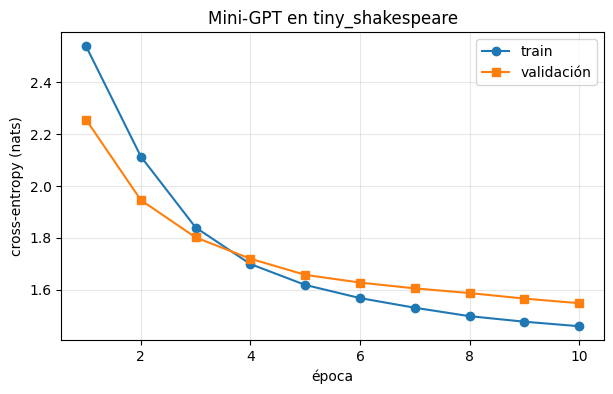

pérdida val: 1.5484 | perplejidad val: 4.704
¿dentro del rango esperado [3.5, 8.0]? True


In [ ]:
# Curvas de pérdida por época
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs+1), train_losses, marker="o", label="train")
plt.plot(range(1, epochs+1), val_losses,   marker="s", label="validación")
plt.xlabel("época"); plt.ylabel("cross-entropy (nats)"); plt.title("Mini-GPT en tiny_shakespeare")
plt.grid(alpha=0.3); plt.legend(); plt.show()


final_val_loss = evaluate_val()
val_ppl = math.exp(final_val_loss)
print(f"pérdida val: {final_val_loss:.4f} | perplejidad val: {val_ppl:.3f}")
print("¿dentro del rango esperado [3.5, 8.0]?", 3.5 <= val_ppl <= 8.0)

**Nota sobre la perplejidad:** interpretarla como "factor de ramificación efectivo": una perplejidad de ~5 significa que, en promedio, el modelo está tan incierto como si eligiera uniformemente entre ~5 caracteres (de 65 posibles; azar puro sería 65). Si sale por encima de 8, sube `steps_per_epoch`; si train baja mucho y val sube, hay sobreajuste (sube `dropout`).

## Task 1.3  Funciones de muestreo desde cero

In [ ]:


def sample_greedy(logits):

    return int(torch.argmax(logits).item())

def sample_top_k(logits, k, tau):

    z = logits / tau

    k = min(k, z.numel())
    kth_value = torch.sort(z, descending=True).values[k - 1]
    z = torch.where(z < kth_value, torch.full_like(z, float("-inf")), z)
    probs = torch.softmax(z, dim=-1)

    return int(torch.multinomial(probs, num_samples=1).item())

def sample_top_p(logits, p, tau):

    probs = torch.softmax(logits / tau, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    keep = (cumulative - sorted_probs) < p
    nucleus_probs = torch.where(keep, sorted_probs, torch.zeros_like(sorted_probs))

    nucleus_probs = nucleus_probs / nucleus_probs.sum()
    choice = torch.multinomial(nucleus_probs, num_samples=1)
    return int(sorted_idx[choice].item())

test_logits = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0])
print("greedy:", sample_greedy(test_logits))                                        # 0
draws = [sample_top_k(test_logits, k=2, tau=1.0) for _ in range(2000)]
print("top-k k=2 solo debe producir {0,1}:", sorted(set(draws)))
draws = [sample_top_p(test_logits, p=0.5, tau=1.0) for _ in range(2000)]
print("top-p p=0.5 (P(0)≈0.51 ya supera 0.5) solo debe producir {0}:", sorted(set(draws)))

greedy: 0
top-k k=2 solo debe producir {0,1}: [0, 1]
top-p p=0.5 (P(0)≈0.51 ya supera 0.5) solo debe producir {0}: [0]


## Task 2.1 `generate` y las 5 configuraciones

In [ ]:
@torch.no_grad()
def generate(prompt, max_new_tokens, strategy, return_trace=False, **kwargs):
#top p
    model.eval()
    ids = encode(prompt)
    nucleus_sizes, entropies = [], []
    for _ in range(max_new_tokens):
        ctx = torch.tensor([ids[-block_size:]], device=device)   # ultimos bloques
        logits, _ = model(ctx)
        logits = logits[0, -1, :]                               
        if strategy == "greedy":
            nxt = sample_greedy(logits)
        elif strategy == "top_k":
            nxt = sample_top_k(logits, kwargs["k"], kwargs["tau"])
        elif strategy == "top_p":
            nxt = sample_top_p(logits, kwargs["p"], kwargs["tau"])
        else:
            raise ValueError(strategy)
        if return_trace:
            pr = torch.softmax(logits / kwargs.get("tau", 1.0), dim=-1)
            entropies.append(float(-(pr * torch.log(pr + 1e-12)).sum()))
            if strategy == "top_p":
                sp = torch.sort(pr, descending=True).values
                nucleus_sizes.append(int(((torch.cumsum(sp, 0) - sp) < kwargs["p"]).sum()))
        ids.append(nxt)
    out = decode(ids)
    return (out, nucleus_sizes, entropies) if return_trace else out

configs = {
    "A": dict(strategy="greedy"),
    "B": dict(strategy="top_k", k=5,  tau=0.7),
    "C": dict(strategy="top_k", k=50, tau=1.0),
    "D": dict(strategy="top_p", p=0.70, tau=0.7),
    "E": dict(strategy="top_p", p=0.95, tau=1.0),
}

In [ ]:
torch.manual_seed(SEED)   # seed
samples = {}
for name, cfg in configs.items():
    samples[name] = [generate("ROMEO:", 200, **cfg) for _ in range(5)]
    print("=" * 70); print(f"Configuración {name}: {cfg}"); print("=" * 70)
    for i, s in enumerate(samples[name], 1):
        print(f"--- muestra {name}{i} ---"); print(s); print()

Configuración A: {'strategy': 'greedy'}
--- muestra A1 ---
ROMEO:
The stand of the country of the country's death.

MERCUTIO:
What is the stand of the country of the stand,
And the stand of the state of the state of the stands
That the stand of the state of the sta

--- muestra A2 ---
ROMEO:
The stand of the country of the country's death.

MERCUTIO:
What is the stand of the country of the stand,
And the stand of the state of the state of the stands
That the stand of the state of the sta

--- muestra A3 ---
ROMEO:
The stand of the country of the country's death.

MERCUTIO:
What is the stand of the country of the stand,
And the stand of the state of the state of the stands
That the stand of the state of the sta

--- muestra A4 ---
ROMEO:
The stand of the country of the country's death.

MERCUTIO:
What is the stand of the country of the stand,
And the stand of the state of the state of the stands
That the stand of the state of the sta

--- muestra A5 ---
ROMEO:
The stand of the country o

## Task 2.2 — Análisis

In [ ]:

def distinct_ngrams(s, n): 
    g = [s[i:i+n] for i in range(len(s)-n+1)]
    return len(set(g)) / max(1, len(g))

for name, ss in samples.items():
    d3 = sum(distinct_ngrams(s, 3) for s in ss) / len(ss)
    uniq = len(set(ss))
    print(f"{name}: muestras únicas = {uniq}/5 | trigramas distintos (proporción) = {d3:.2f}")


A: muestras únicas = 1/5 | trigramas distintos (proporción) = 0.36
B: muestras únicas = 5/5 | trigramas distintos (proporción) = 0.74
C: muestras únicas = 5/5 | trigramas distintos (proporción) = 0.88
D: muestras únicas = 5/5 | trigramas distintos (proporción) = 0.78
E: muestras únicas = 5/5 | trigramas distintos (proporción) = 0.88


ROMEO:
By true subtle; speak you the night looks of my story
gentleman the night and to bear heart me,
That should all prove make him it the each of thy should
Be the rocks, it is the fings of determine one

MUY SEGURO (núcleo de 1-2 candidatos) — primeros ejemplos con contexto:
  pos   0 | ...'' -> '\n' | núcleo=1 | H=0.01
  pos   3 | ...'\nBy' -> ' ' | núcleo=1 | H=0.14
  pos   5 | ...'\nBy t' -> 'r' | núcleo=2 | H=0.36
  pos  14 | ...'true subtl' -> 'e' | núcleo=1 | H=0.24
  pos  16 | ...'ue subtle;' -> ' ' | núcleo=2 | H=0.57
  pos  20 | ...'ubtle; spe' -> 'a' | núcleo=2 | H=0.51
  pos  21 | ...'btle; spea' -> 'k' | núcleo=1 | H=0.01
  pos  24 | ...'e; speak y' -> 'o' | núcleo=2 | H=0.24
  pos  25 | ...'; speak yo' -> 'u' | núcleo=1 | H=0.01
  pos  34 | ...'ou the nig' -> 'h' | núcleo=1 | H=0.01

INSEGURO (núcleo más grande) — los 10 mayores:
  pos  55 | ...' my story\n' -> 'g' | núcleo=35 | H=3.41
  pos 154 | ...'hy should\n' -> 'B' | núcleo=33 | H=3.18
  pos 187 | ...' fings of '

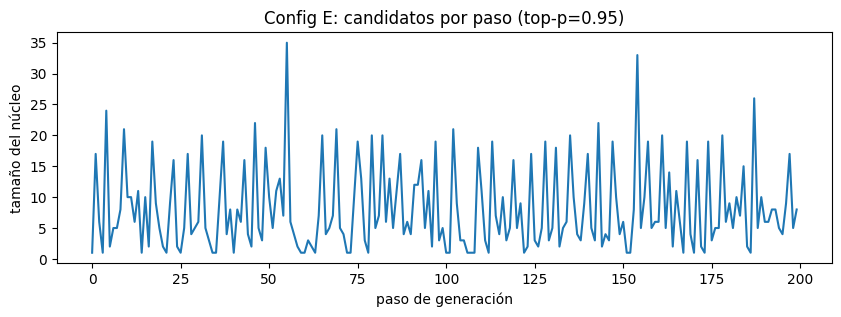

In [ ]:

torch.manual_seed(SEED)
text_E, nuc, ent = generate("ROMEO:", 200, strategy="top_p", p=0.95, tau=1.0, return_trace=True)
print(text_E); print()
gen = text_E[len("ROMEO:"):]
rows = list(zip(range(len(gen)), gen, nuc, ent))

print("MUY SEGURO (núcleo de 1-2 candidatos) — primeros ejemplos con contexto:")
for i, ch, s, h in [r for r in rows if r[2] <= 2][:10]:
    print(f"  pos {i:3d} | ...{gen[max(0,i-10):i]!r} -> {ch!r} | núcleo={s} | H={h:.2f}")

print("\nINSEGURO (núcleo más grande) — los 10 mayores:")
for i, ch, s, h in sorted(rows, key=lambda r: -r[2])[:10]:
    print(f"  pos {i:3d} | ...{gen[max(0,i-10):i]!r} -> {ch!r} | núcleo={s} | H={h:.2f}")

plt.figure(figsize=(10, 3)); plt.plot(nuc); plt.xlabel("paso de generación"); plt.ylabel("tamaño del núcleo")
plt.title("Config E: candidatos por paso (top-p=0.95)"); plt.show()

### a. Por qué greedy (A) repite o entra en ciclos

**Definición:** $x_{t+1} = \arg\max_i z_i$ (equivale al argmax de $P(w_i\mid ctx)$ porque softmax es monótono). No hay aleatoriedad: la generación es una función determinista del contexto, $x_{t+1}=f(x_{t-127:t})$. Como el contexto efectivo es finito (128 caracteres sobre un alfabeto de 65) y $f$ es determinista, en cuanto el contexto se repite la secuencia entera se repite: la trayectoria termina necesariamente en un **ciclo**.

**Forma de la distribución:** entrenado con cross-entropy, el modelo aprende distribuciones muy **concentradas** en muchas posiciones (en la corrida hay posiciones con entropía ≈ 0.01 nats, es decir, prácticamente un solo carácter posible). Greedy siempre toma la moda, sigue el "camino de mayor probabilidad" y nunca explora alternativas razonables que el muestreo sí visitaría. Además hay retroalimentación: cuando el contexto ya contiene un fragmento repetido, el modelo tiende a copiarlo, lo que refuerza el ciclo.

**Con mis muestras:** las cinco muestras A1…A5 son **idénticas** (`muestras únicas = 1/5`), porque no hay azar. El texto cae rápido en un bucle de la forma "of the state of the state": *"And the stand of the state of the state of the stands / That the stand of the state of the sta…"*. Ya desde el inicio aparece *"The stand of the country of the country's death"*, donde "of the country" se repite. La proporción de trigramas distintos es de solo **0.36**, frente a 0.74-0.88 en B-E.

### b. Comparación de B (k=5, τ=0.7) y C (k=50, τ=1.0)

La temperatura reescala los logits: $P(w_i\mid ctx)=\dfrac{e^{z_i/\tau}}{\sum_j e^{z_j/\tau}}$, y la razón entre dos tokens es $\dfrac{P_i}{P_j}=e^{(z_i-z_j)/\tau}$.

- **Efecto de τ: 0.7 → 1.0.** Con τ=0.7 las diferencias de logit se multiplican por $1/0.7\approx1.43$: el token líder gana masa y la distribución queda **más concentrada** (menor entropía). Con τ=1.0 se usa la distribución tal como la aprendió el modelo: más plana, con más masa en la cola.
- **Efecto de k: 5 → 50.** Top-k recorta el soporte a los k logits mayores. Con k=5 solo compiten 5 caracteres y los demás tienen probabilidad exactamente 0. Con k=50 de 65 posibles el recorte casi no filtra nada, y entran caracteres poco probables que producen errores ortográficos. Más k = más **diversidad**.
- **Efecto combinado:** B = soporte chico + distribución afilada (poca aleatoriedad). C = soporte casi completo + temperatura sin afilar (mucha aleatoriedad). Como cambian ambos parámetros a la vez, con estas muestras no se puede atribuir cada efecto por separado; para aislarlos habría que variar uno solo (por ejemplo k=50 con τ=0.7).

**Con mis muestras:** la métrica de trigramas distintos sube de **0.74 (B)** a **0.88 (C)**, así que C es más diverso. B produce casi siempre palabras bien formadas, por ejemplo *"Now, aside, the stay of the cause."* o *"The wars in the worship of the contract will."*, aunque con sintaxis floja y muchas palabras funcionales repetidas ("the … of the"), típico de τ bajo favoreciendo los tokens más frecuentes. C es más variado pero con más errores: *"Kme it."*, *"The Servies of HerefrY Vaugham"*, *"so against upon ssit"*, *"good gand"*. **B es más coherente** (a nivel de palabra y de estructura de diálogo) y **C más creativo**, a costa de inventar palabras y de mayúsculas fuera de lugar. Ninguno es coherente a nivel de frase, algo esperable en un modelo de 0.63 M parámetros.

### c. Config E (top-p=0.95, τ=1.0) es adaptativa

El núcleo es el mínimo número de tokens cuya masa acumulada supera 0.95. Si el modelo está seguro, un solo token ya supera 0.95 (núcleo = 1); si está inseguro, la masa se reparte y el núcleo crece a decenas de tokens. Las citas salen de la celda de traza (una corrida aparte de E, con otro texto que E1-E5, pero con la misma configuración).

**Momentos de alta seguridad** (núcleo 1, entropía ≈ 0.01 nats):
1. Completar *"spea"* → **k** en *"speak"* (pos 21; H = 0.01).
2. Completar *"yo"* → **u** en *"you"* (pos 25; H = 0.01).
3. Completar *"nig"* → **h** en *"night"* (pos 34; H = 0.01).
4. El **salto de línea** justo tras el prompt *"ROMEO:"* (pos 0; núcleo 1, H = 0.01).

Patrón: son **letras intermedias de palabras ya empezadas** (el inglés deja pocas continuaciones tras *"spea"* o *"nig"*) y el cierre de una etiqueta de personaje con `:` seguida de `\n`.

**Momentos de inseguridad** (núcleos grandes, H ≈ 3 nats; el máximo posible con 65 caracteres es ln 65 ≈ 4.17):
1. Primera letra tras *"my story\n"* → **g** (pos 55; núcleo = 35, H = 3.41).
2. Inicio de línea tras *"thy should\n"* → **B** (pos 154; núcleo = 33, H = 3.18).
3. Primera letra tras *"fings of "* → **d** (pos 187; núcleo = 26) y tras *"looks of "* → **m** (pos 46; núcleo = 22).

Patrón: son **inicios de palabra o de línea**, sobre todo tras `\n` (¿qué verso o personaje sigue?) y tras palabras funcionales como *of* o *the*, donde puede venir casi cualquier sustantivo. La decisión pasa de ser ortográfica (dentro de la palabra) a ser semántica (qué palabra sigue).

**Por qué importa:** top-p se adapta a esto, con pocos candidatos dentro de las palabras y muchos en los límites, mientras que top-k usa un k fijo en ambos casos. Eso ayuda a explicar por qué E alcanza la misma diversidad que C (0.88 de trigramas distintos) sin depender de un k arbitrario.